In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import softmax
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import TextVectorization

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
dev = tf.config.list_physical_devices()
print('Physical Devices : ', dev)

#tf.config.set_visible_devices(dev[0])
#tf.config.set_visible_devices(dev[1])
dev = tf.config.list_logical_devices()
print('Available Devices : ', dev)

Physical Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Available Devices :  [LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]


I0000 00:00:1750711498.660742   67737 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


# Chapter 12: Generative Deep Learning

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

Generative AI and using deep learning architectures is particulary popular right now,
though I personally agree with the assessment that it "has fed a (not so) short-lived hype
wave worthy of the most torrid AI summer.  In any case, the promise of generative AI is that
it can be used as a tool to augment human capabilities, so more generative augmentive intelligence
rather than artifical general intelligence.

In this section we will look at some of the basic mechanisms and architectures for building generative
systems using deep learning networks.  We will look at generating text and images, and
what autoencoders and GAN networks are all about.

## 12.4 Generating Images with Variational Autoencoders

### 12.4.1 Sampling from Latent Spaces of Images

### 12.4.2 Concept Vectors for Image Editing

### 12.4.3 Variational Autoencoders

### 12.4.4 Implementing a VAE with Keras

We’re going to be implementing a VAE that can generate MNIST digits. It’s going to
have three parts:
- An encoder network that turns a real image into a mean and a variance in the
  latent space
- A sampling layer that takes such a mean and variance, and uses them to sample
  a random point from the latent space
- A decoder network that turns points from the latent space back into images

The following listing shows the encoder network we’ll use, mapping images to the
parameters of a probability distribution over the latent space.

It’s a simple convnet that maps the input image x to two vectors, z_mean and z_log_var.

One important detail is that we use strides for downsampling feature maps instead of max pooling.

In [4]:
# VAE encoder network, input mnist greyscale images, 
# 2 outputs, the z_mean and z_log_var

# dimensionality of the latent space: a 2D plane!
latent_dim = 2

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
# the input image ends up being encoded into these two parameters
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var], name="encoder")

In [5]:
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

Next is the code for using `z_mean` and `z_log_var`, the parameters of the statistical
distribution assumed to have produced `input_img`, to generate a latent space point `z`.

In [6]:
# latent space sampling layer
class Sampler(layers.Layer):
    def call(self, z_mean, z_log_var):
        # draw a batch of random normal vectors
        batch_size = tf.shape(z_mean)[0]
        z_size = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch_size, z_size))

        # apply the VAE sampling formula
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


The following listing shows the decoder implementation.  We reshape the vector `z`
to the dimensions of an image and then use a few convolution layers to obtain
a final image output. that has the same dimensions as the original `input_img`.

In [7]:
# VAE decoder network, mapping latent space points to images
# inputs where we'll feed z
latent_inputs = keras.Input(shape=(latent_dim,))

# produce the same number of coefficients that we had at the level of the
# flatten layer in the encoder (see summary above).
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)

# revert the flatten layer of the encoder
x = layers.Reshape((7, 7, 64))(x)

# revert the conv2d layers of the encoder
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)

# the output ends up with shape (28, 28, 1)
decoder_outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

Now let's create the VAE model itself.  

This is our first example of a model that isn’t
doing supervised learning.  An autoencoder is an example of self-supervised learning,
because it uses its inputs as targets.

Whenever you depart from classic supervised
learning, it’s common to subclass the Model class and implement a custom 
`train_step()` to specify the new training logic


In [8]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampler = Sampler()

        # we use these metrics to keep track of the loss averages over each epoch
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        """List metrics in the metrics member function to enable the model to reset them
        after each epoch
        """
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(data)
            z = self.sampler(z_mean, z_log_var)
            reconstruction = decoder(z)

            # we sum the reconstruction loss over the spatial dimensions (axes 1 and 2)
            # and take its mean over the batch dimension
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction),axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            total_loss = reconstruction_loss + tf.reduce_mean(kl_loss)
            grads = tape.gradient(total_loss, self.trainable_weights)
            self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
            self.total_loss_tracker.update_state(total_loss)
            self.reconstruction_loss_tracker.update_state(reconstruction_loss)

            # add the regularization term (Kullback-Leibler divergence)
            self.kl_loss_tracker.update_state(kl_loss)
            return {
                "total_loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.reconstruction_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result(),
            }

Finally we are ready to instantiate and train the model on MNIST digits.

Because the loss is taken care of in the custom layer, we don’t specify an external loss at compile
time (`loss=None`), which in turn means we won’t pass target data during training (as
you can see, we only pass `x_train` to the model in `fit()`).

In [9]:
# we train on all MNIST digits, so we concatenate the training and test samples
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
mnist_digits = np.concatenate([x_train, x_test], axis=0)
mnist_digits = np.expand_dims(mnist_digits, -1).astype("float32") / 255

# create our VAE, using our already instanted encoder and decoder
vae = VAE(encoder, decoder)

# we don't pass in loss to compile since loss is already part of the train_step
vae.compile(optimizer=keras.optimizers.Adam(), run_eagerly=True)

# we don't pass targets in fit, since train_step doesn't expect any.
vae.fit(mnist_digits, epochs=30, batch_size=128)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/30


I0000 00:00:1750715275.037922   67737 cuda_dnn.cc:529] Loaded cuDNN version 90300


547/547 ━━━━━━━━━━━━━━━━━━━━ 58s 102ms/step - kl_loss: 2.5376 - reconstruction_loss: 248.1911 - total_loss: 250.7288
Epoch 2/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 55s 100ms/step - kl_loss: 3.5656 - reconstruction_loss: 165.6688 - total_loss: 169.2344
Epoch 3/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 54s 99ms/step - kl_loss: 3.5246 - reconstruction_loss: 158.5310 - total_loss: 162.0556
Epoch 4/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 57s 104ms/step - kl_loss: 3.5412 - reconstruction_loss: 154.7412 - total_loss: 158.2824
Epoch 5/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 55s 101ms/step - kl_loss: 3.5697 - reconstruction_loss: 152.7690 - total_loss: 156.3388
Epoch 6/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 57s 104ms/step - kl_loss: 3.6003 - reconstruction_loss: 151.0164 - total_loss: 154.6167
Epoch 7/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 55s 101ms/step - kl_loss: 3.6125 - reconstruction_loss: 150.2152 - total_loss: 153.8277
Epoch 8/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 57s 104ms/step - kl_loss: 3.6539 - reconstruction_loss: 148.9847 - total_los

Once the model is trained, we can use the decoder network to turn arbitrary latent space vectors into
images.  

**Note** takes some time to complete, and we have turned off reporting by the call to `predict()` since
there are 900 of them.

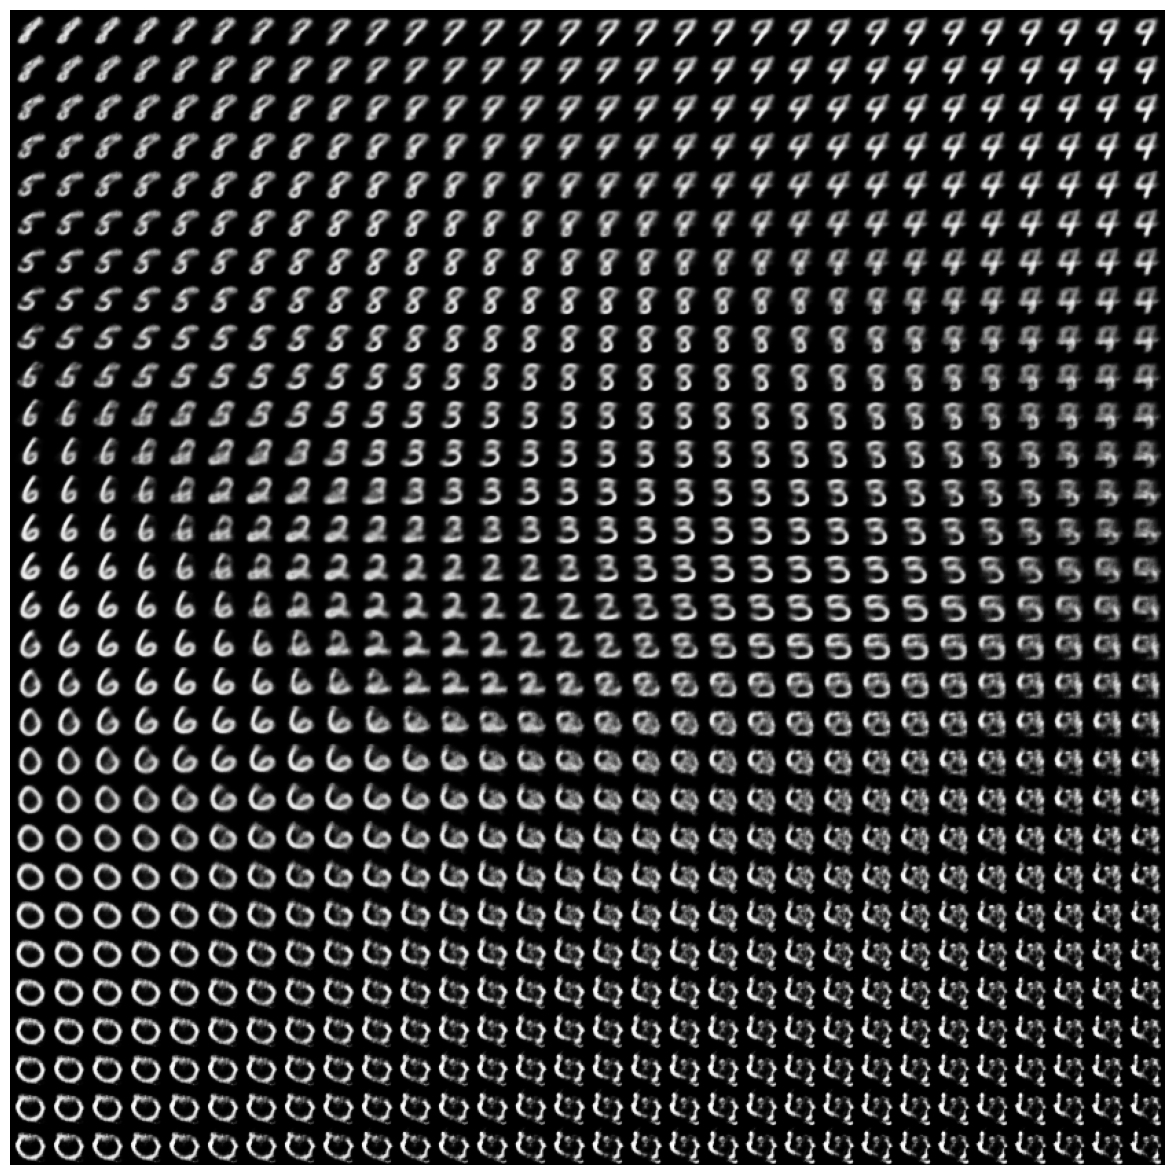

In [11]:
# we'll display a grid of 30 x 30 digits (900 total digits)
n = 30
digit_size = 28
# a single composite figure, the sampled digits are placed in this array and all displayed
# as a single figure
figure = np.zeros((digit_size * n, digit_size * n))

# sample points linearly on a 2D grid
grid_x = np.linspace(-1, 1, n)
grid_y = np.linspace(-1, 1, n)[::-1]

# iterate over the y and x grid locations
for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        # for each location sample a digit and add it to our figure
        z_sample = np.array([[xi, yi]])
        x_decoded = vae.decoder.predict(z_sample, verbose=False)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit

plt.figure(figsize=(15, 15))
start_range = digit_size // 2
end_range = n * digit_size + start_range
pixel_range = np.arange(start_range, end_range, digit_size)
sample_range_x = np.round(grid_x, 1)
sample_range_y = np.round(grid_y, 1)
plt.xticks(pixel_range, sample_range_x)
plt.yticks(pixel_range, sample_range_y)
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.axis("off")
plt.imshow(figure, cmap="Greys_r");

The grid of sampled digits shows a completely continuous distribution of the different digit classes.

With one digit morphing into another as you follow a path through latent space.

Specific directions in this space have a meaning: for exampler there are directions for "five-ness", "one-ness", and so on.

## Summary

<font color='blue'>
    
- Image generation with deep learning is done by learning latent spaces that capture
  statistical information about a dataset of images. By sampling and decoding
  points from the latent space, you can generate never-before-seen images.
  There are two major tools to do this: VAEs and GANs.
- VAEs result in highly structured, continuous latent representations. For this reason,
  they work well for doing all sorts of image editing in latent space: face
  swapping, turning a frowning face into a smiling face, and so on. They also work
  nicely for doing latent-space-based animations, such as animating a walk along a
  cross section of the latent space or showing a starting image slowly morphing
  into different images in a continuous way.
- GANs enable the generation of realistic single-frame images but may not induce
  latent spaces with solid structure and high continuity.